## Figure 1B & S1B

In [2]:
import os
import torch
import torch.nn as nn
from torch.nn import Module, ModuleList
import torch.nn.functional as F
from typing import List, Tuple, Optional, Union
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import esm

try:
    from esm.modules import TransformerLayer, ESM1bLayerNorm, RobertaLMHead
    from esm.multihead_attention import MultiheadAttention
except ImportError:
    print("Error: Could not import required classes from 'esm'.")
    print("Please ensure 'fair-esm' is installed: pip install fair-esm")

class ConvUnetAttentionLayer(Module):
    def __init__(
        self,
        embed_dim: int,
        ffn_embed_dim: int,
        attention_heads: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.attention_heads = attention_heads
        
        self.pre_norm = ESM1bLayerNorm(embed_dim)
        self.activation = nn.GELU()
        
        self.conv1 = nn.Conv1d(embed_dim, embed_dim, kernel_size=5, padding=2)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2) 
        
        self.conv2 = nn.Conv1d(embed_dim, embed_dim, kernel_size=7, padding=3)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.bottleneck_transformer = TransformerLayer(
            embed_dim=embed_dim,
            ffn_embed_dim=ffn_embed_dim,
            attention_heads=attention_heads,
            add_bias_kv=False,
            use_esm1b_layer_norm=True,
            use_rotary_embeddings=True,
        )
        
        self.unpool1 = nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=2, stride=2)
        self.tconv1 = nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=7, padding=3)
        self.norm_t1 = nn.LayerNorm(embed_dim)

        self.unpool2 = nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=2, stride=2)
        self.tconv2 = nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=5, padding=2)
        self.norm_t2 = nn.LayerNorm(embed_dim)
        
        self.dropout_layer = nn.Dropout(dropout)

    def _apply_norm(self, norm_layer, x_conv):
        x_permuted = x_conv.permute(0, 2, 1)
        x_normed = norm_layer(x_permuted)
        x_restored = x_normed.permute(0, 2, 1)
        return x_restored

    def forward(
        self,
        x: torch.Tensor,
        self_attn_padding_mask: Optional[torch.Tensor] = None,
        need_head_weights: bool = False,
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        
        x_residual = x
        x_normed = self.pre_norm(x)
        x_conv = x_normed.permute(1, 2, 0)

        h_conv1 = self.conv1(x_conv)
        skip1 = self.activation(self._apply_norm(self.norm1, h_conv1))
        h_pool1 = self.pool1(skip1)

        h_conv2 = self.conv2(h_pool1)
        skip2 = self.activation(self._apply_norm(self.norm2, h_conv2))
        h_pool2 = self.pool2(skip2)

        h_attn_in = h_pool2.permute(2, 0, 1)
        
        pooled_padding_mask = None
        if self_attn_padding_mask is not None:
            mask_for_pooling = self_attn_padding_mask.float().unsqueeze(1)
            pooled_mask_1 = F.max_pool1d(mask_for_pooling, kernel_size=2, stride=2)
            pooled_mask_2 = F.max_pool1d(pooled_mask_1, kernel_size=2, stride=2).bool()
            pooled_padding_mask = pooled_mask_2.squeeze(1)
            
        attn_out, attn_weights = self.bottleneck_transformer(
            h_attn_in,
            self_attn_padding_mask=pooled_padding_mask,
            need_head_weights=need_head_weights,
        )

        h_upsample_in = attn_out.permute(1, 2, 0)

        h_up1 = self.unpool1(h_upsample_in)
        h_up1_tconv = self.tconv1(h_up1 + skip2)
        h_up1 = self.activation(self._apply_norm(self.norm_t1, h_up1_tconv)) 

        h_up2 = self.unpool2(h_up1)
        h_up2_tconv = self.tconv2(h_up2 + skip1)
        h_up2 = self.activation(self._apply_norm(self.norm_t2, h_up2_tconv)) 

        x_out = h_up2.permute(2, 0, 1)
        
        x = x_residual + self.dropout_layer(x_out)

        return x, attn_weights

class ProtWord_Encoder(nn.Module):
    def __init__(
        self,
        num_layers: int = 33,
        embed_dim: int = 1280,
        attention_heads: int = 20,
        alphabet: Union[esm.data.Alphabet, str] = "ESM-1b",
        token_dropout: bool = True
    ):
        super().__init__()
        self.num_layers = num_layers
        self.embed_dim = embed_dim
        self.attention_heads = attention_heads
        
        if not isinstance(alphabet, esm.data.Alphabet):
            alphabet = esm.data.Alphabet.from_architecture(alphabet)
        self.alphabet = alphabet
        self.alphabet_size = len(alphabet)
        self.padding_idx = alphabet.padding_idx
        self.mask_idx = alphabet.mask_idx
        self.token_dropout = token_dropout
        self._init_submodules()
    def _init_submodules(self):
        self.embed_scale = 1
        self.embed_tokens = nn.Embedding(
            self.alphabet_size,
            self.embed_dim,
            padding_idx=self.padding_idx,
        )
        self.layers = nn.ModuleList(
            [
                ConvUnetAttentionLayer(
                    self.embed_dim,
                    4 * self.embed_dim,
                    self.attention_heads,
                    dropout=0.1,
                )
                for _ in range(self.num_layers)
            ]
        )
        
        self.emb_layer_norm_after = ESM1bLayerNorm(self.embed_dim)
        self.lm_head = RobertaLMHead(
            embed_dim=self.embed_dim,
            output_dim=self.alphabet_size,
            weight=self.embed_tokens.weight,
        )

    def forward(self, tokens, repr_layers=[], need_head_weights=False):
        assert tokens.ndim == 2
        padding_mask = tokens.eq(self.padding_idx)
        
        x = self.embed_scale * self.embed_tokens(tokens)
        
        if self.token_dropout:
            x.masked_fill_((tokens == self.mask_idx).unsqueeze(-1), 0.0)
            mask_ratio_train = 0.15 * 0.8
            src_lengths = (~padding_mask).sum(-1)
            src_lengths[src_lengths == 0] = 1 
            mask_ratio_observed = (tokens == self.mask_idx).sum(-1).to(x.dtype) / src_lengths
            denominator = (1 - mask_ratio_observed)[:, None, None]
            denominator_clipped = torch.clamp(denominator, min=0.5) 
            x = x * (1 - mask_ratio_train) / denominator_clipped
            
        if padding_mask is not None:
            x = x * (1 - padding_mask.unsqueeze(-1).type_as(x))
            
        repr_layers = set(repr_layers)
        hidden_representations = {}
        if 0 in repr_layers:
            hidden_representations[0] = x
            
        if need_head_weights:
            attn_weights = []
        x = x.transpose(0, 1)
        
        if not padding_mask.any():
            padding_mask = None
            
        for layer_idx, layer in enumerate(self.layers):
            x, attn = layer(
                x,
                self_attn_padding_mask=padding_mask,
                need_head_weights=need_head_weights,
            )
            if (layer_idx + 1) in repr_layers:
                hidden_representations[layer_idx + 1] = x.transpose(0, 1)
            if need_head_weights:
                attn_weights.append(attn)
                
        x = self.emb_layer_norm_after(x)
        x = x.transpose(0, 1)
        
        if self.num_layers in repr_layers: 
            hidden_representations[self.num_layers] = x
        x = self.lm_head(x)
        
        result = {"logits": x, "representations": hidden_representations}
        if need_head_weights:
            attentions = torch.stack(attn_weights, 1)
            result["attentions"] = attentions
        return result

In [3]:
MODEL_PATH = "../RELIC_ckpt//encoder_t12_150M.pth"
NUM_LAYERS = 12
EMBED_DIM = 560
ATTENTION_HEADS = 20

print(f"Configuration set:")
print(f"  Model Path: {MODEL_PATH}")
print(f"  Model Arch: L={NUM_LAYERS}, D={EMBED_DIM}, H={ATTENTION_HEADS}")

Configuration set:
  Model Path: ../RELIC_ckpt//encoder_t12_150M.pth
  Model Arch: L=12, D=560, H=20


In [8]:
from collections import OrderedDict
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
alphabet = esm.data.Alphabet.from_architecture("ESM-1b")
print("Initializing model...")
model = ProtWord_Encoder(
    num_layers=NUM_LAYERS,
    embed_dim=EMBED_DIM,
    attention_heads=ATTENTION_HEADS,
    alphabet=alphabet,
    token_dropout=False
)
state_dict = torch.load(MODEL_PATH, map_location="cpu")
new_state_dict = OrderedDict()
prefix = "_orig_mod."
for k, v in state_dict.items():
    if k.startswith(prefix):
        name = k[len(prefix):]
        new_state_dict[name] = v
    else:
        new_state_dict[k] = v
try:
    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()
    print("Model loaded successfully.")
except FileNotFoundError:
    print(f"Error: Model file not found at {MODEL_PATH}")
except RuntimeError as e:
    print(f"Error loading state_dict: {e}")
    print("Please ensure your model architecture parameters in Cell 4")
    print("(NUM_LAYERS, EMBED_DIM, ATTENTION_HEADS) exactly match the checkpoint.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Using device: cuda
Initializing model...
Model loaded successfully.


Processing ADGRD1...
Processing PLP1...
Processing corB...
Processing IFT122...
Processing SLC3A1...
Processing GPR155...


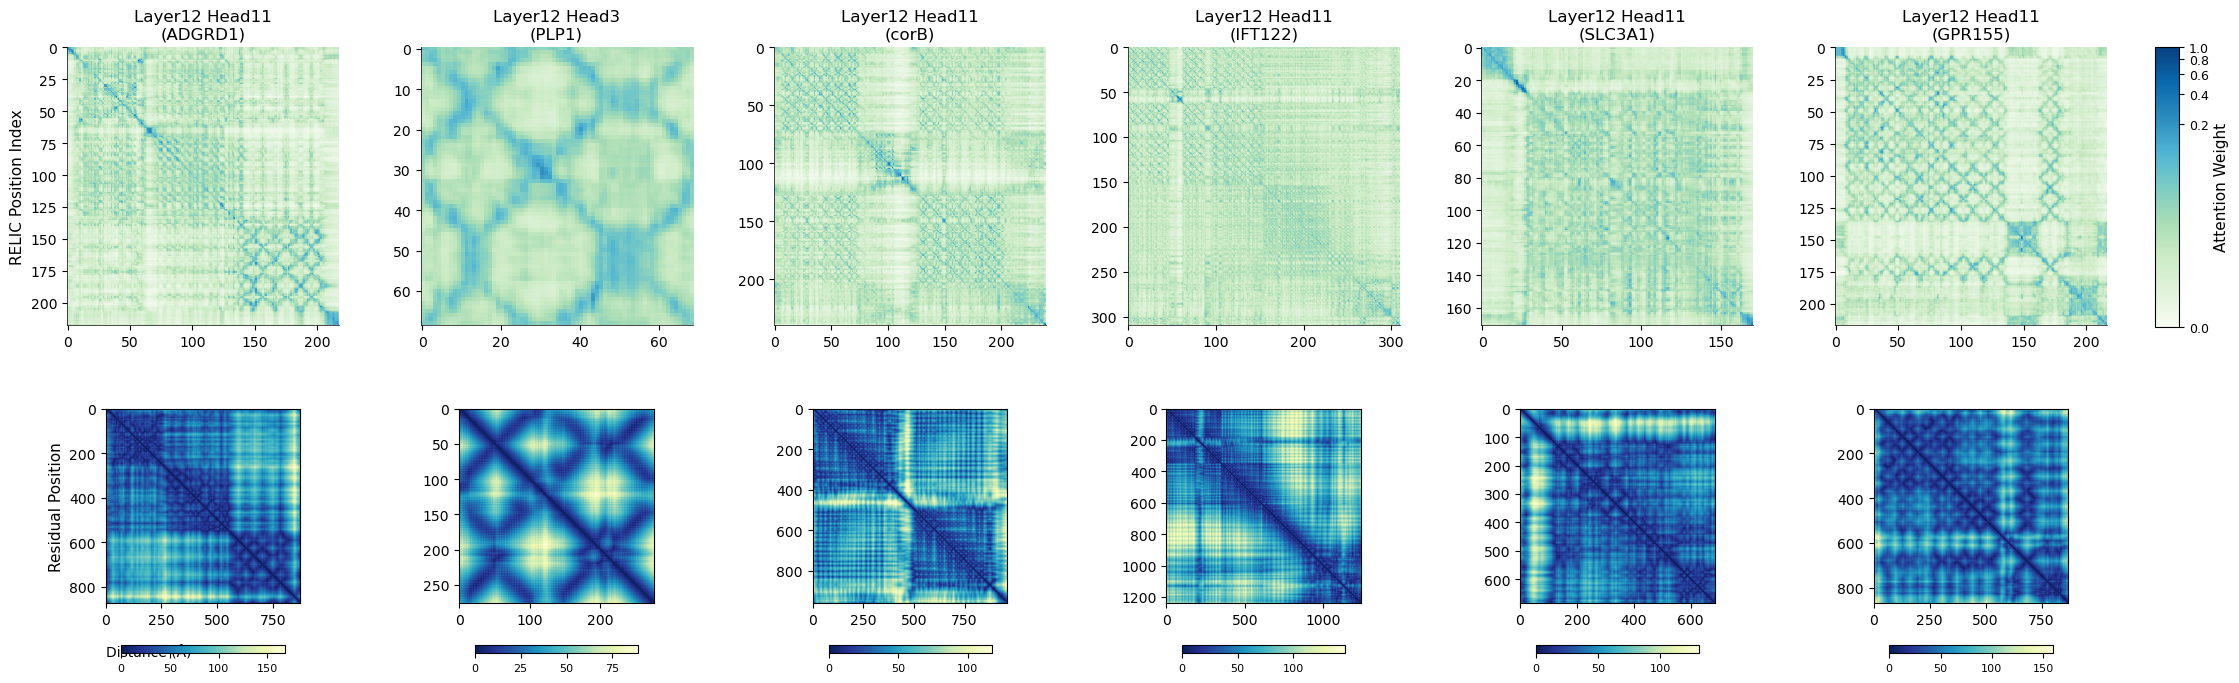

In [12]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from Bio.PDB import PDBParser, PPBuilder
protein_configs = [
    {
        "pdb_path": "../RELIC_data/figure1B/ADGRD1.pdb",
        "layer_idx": 11,
        "head_idx": 10, 
    },
    {
        "pdb_path": "../RELIC_data/figure1B/PLP1.pdb",
        "layer_idx": 11,
        "head_idx": 2, 
    },
    {
        "pdb_path": "../RELIC_data/figure1B/corB.pdb",
        "layer_idx": 11,
        "head_idx": 10, 
    },
    {
        "pdb_path": "../RELIC_data/figure1B/IFT122.pdb",
        "layer_idx": 11,
        "head_idx": 10, 
    },
    {
        "pdb_path": "../RELIC_data/figure1B/SLC3A1.pdb",
        "layer_idx": 11,
        "head_idx": 10, 
    },
    {
        "pdb_path": "../RELIC_data/figure1B/GPR155.pdb",
        "layer_idx": 11,
        "head_idx": 10, 
    },
]

norm_attn = mcolors.PowerNorm(gamma=0.2, vmin=0, vmax=1)
cmap_attn = 'GnBu'
cmap_dist = 'YlGnBu_r' 

num_proteins = len(protein_configs)
fig, axes = plt.subplots(nrows=2, ncols=num_proteins, figsize=(4 * num_proteins, 8))

if num_proteins == 1:
    axes = axes.reshape(2, 1)

parser = PDBParser(QUIET=True)
ppb = PPBuilder()

for col, config in enumerate(protein_configs):
    pdb_path = config["pdb_path"]
    l_idx = config["layer_idx"]
    h_idx = config["head_idx"]

    name = os.path.splitext(os.path.basename(pdb_path))[0]
    print(f"Processing {name}...")
    
    try:

        structure = parser.get_structure(name, pdb_path)

        seq = ""
        for pp in ppb.build_peptides(structure):
            seq += str(pp.get_sequence())
            
        if not seq:
            print(f"Warning: Could not extract sequence from {name}.")
            continue

        ca_atoms = [atom for atom in structure.get_atoms() if atom.name == 'CA']
        if not ca_atoms:
            print(f"Warning: No CA atoms found for {name}.")
            continue

        target_len = int(len(seq) // 4) * 4 + 6
        if len(seq) < target_len:
            padding_len = target_len - len(seq)
            processed_sequence = seq + ('<pad>' * padding_len)
        else:
            processed_sequence = seq

        final_seq_str = f"<cls>{processed_sequence}<eos>"
        token_ids = alphabet.encode(final_seq_str)
        tokens = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)
        
        with torch.no_grad():
            results = model(tokens, need_head_weights=True)
        
        attention = results['attentions'].detach().cpu().numpy()
        attn_map = attention[h_idx, l_idx, 0, :len(seq)//4, :len(seq)//4]
        
        ax_attn = axes[0, col]
        im_attn = ax_attn.imshow(attn_map, aspect='auto', cmap=cmap_attn, norm=norm_attn, interpolation='nearest')
        
        ax_attn.set_title(f"Layer{l_idx+1} Head{h_idx+1}\n({name})", fontsize=12)
        ax_attn.spines['top'].set_visible(False)
        ax_attn.spines['right'].set_visible(False)
        ax_attn.spines['left'].set_linewidth(0.5)
        ax_attn.spines['bottom'].set_linewidth(0.5)
        
        if col == 0:
            ax_attn.set_ylabel("RELIC Position Index", fontsize=11)

        coords = np.array([atom.coord for atom in ca_atoms])
        diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
        dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))
        
        ax_dist = axes[1, col]
        im_dist = ax_dist.imshow(dist_matrix, cmap=cmap_dist, origin='upper', interpolation='nearest')
        
        if col == 0:
            ax_dist.set_ylabel("Residual Position", fontsize=11)
            
        cbar_dist = fig.colorbar(im_dist, ax=ax_dist, orientation='horizontal', shrink=0.6, pad=0.15)
        cbar_dist.ax.tick_params(labelsize=8)
        
        if col == 0:
            ax_dist.text(0, -0.25, "Distance (Å)", transform=ax_dist.transAxes, fontsize=10, verticalalignment='center')
                
    except Exception as e:
        print(f"Error processing {name} at {pdb_path}: {e}")

cbar_ax_attn = fig.add_axes([0.92, 0.55, 0.01, 0.35]) 
cbar_attn = fig.colorbar(im_attn, cax=cbar_ax_attn)
cbar_attn.set_label('Attention Weight', size=11)
cbar_attn.ax.tick_params(labelsize=9)

plt.subplots_adjust(left=0.05, right=0.9, top=0.9, bottom=0.1, wspace=0.3, hspace=0.3)
plt.show()

## Figure 1C

In [13]:
import pandas as pd
import numpy as np
from Bio import SeqIO
from sklearn.manifold import TSNE

TSV_PATH = '../RELIC_data/figure1CD/all_vs_all_sw_scope.tsv'  
FASTA_PATH = '../RELIC_data/figure1CD/astral-scopedom-seqres-gd-sel-gs-bib-40-2.01_single.fa'   

def load_data_and_run_tsne():
    print(f"Loading FASTA metadata from {FASTA_PATH}...")
    metadata = []
    
    for record in SeqIO.parse(FASTA_PATH, "fasta"):
        parts = record.description.split()
        if len(parts) >= 2:
            pid = parts[0]
            scope_id = parts[1]
            fold_class = scope_id.split('.')[0] if '.' in scope_id else scope_id[0]
            desc = " ".join(parts[2:])
            
            metadata.append({
                'Protein_ID': pid,
                'SCOPe_Fold': scope_id, 
                'Class': fold_class,
                'Description': desc
            })
            
    meta_df = pd.DataFrame(metadata).set_index('Protein_ID')
    print(f"Found {len(meta_df)} sequences with metadata.")
    print(f"Loading similarity matrix from {TSV_PATH}...")
    df_sim = pd.read_csv(TSV_PATH, sep='\s+', header=None, names=['id1', 'id2', 'score'])
    
    matrix = df_sim.pivot(index='id1', columns='id2', values='score').fillna(0)
    common_ids = sorted(list(set(matrix.index) & set(meta_df.index)))
    
    if not common_ids:
        raise ValueError("Error: No common IDs found between TSV and FASTA!")
        
    print(f"Proteins after intersection: {len(common_ids)}")
    matrix_aligned = matrix.reindex(index=common_ids, columns=common_ids).fillna(0)
    meta_aligned = meta_df.loc[common_ids]
    print("Running Global t-SNE dimensionality reduction...")
    tsne = TSNE(n_components=2, 
                random_state=42, 
                perplexity=5,  
                init='pca', 
                learning_rate='auto',
                n_jobs=-1)
    
    embedding = tsne.fit_transform(matrix_aligned)
    result_df = meta_aligned.copy()
    result_df['tSNE_1'] = embedding[:, 0]
    result_df['tSNE_2'] = embedding[:, 1]
    result_df.reset_index(inplace=True) 
    return matrix_aligned, meta_aligned, result_df
matrix_aligned, meta_aligned, df_plot = load_data_and_run_tsne()

print("Data processing complete.")
df_plot.head()

Loading FASTA metadata from ../RELIC_data/figure1CD/astral-scopedom-seqres-gd-sel-gs-bib-40-2.01_single.fa...
Found 11211 sequences with metadata.
Loading similarity matrix from ../RELIC_data/figure1CD/all_vs_all_sw_scope.tsv...
Proteins after intersection: 11211
Running Global t-SNE dimensionality reduction...
Data processing complete.


,Protein_ID,SCOPe_Fold,Class,Description,tSNE_1,tSNE_2
0,d12asa_,d.104.1.1,d,(A:) Asparagine synthetase {Escherichia coli [...,-87.002632,-68.008362
1,d16vpa_,d.180.1.1,d,(A:) Conserved core of transcriptional regulat...,17.513632,22.297955
2,d1914a1,d.49.1.1,d,(A:4004-4081) Signal recognition particle 9KDa...,-46.653931,37.053291
3,d1914a2,d.49.1.1,d,(A:2001-2097) Signal recognition particle 14KD...,-50.551826,9.153227
4,d1a04a1,a.4.6.2,a,(A:150-216) Nitrate/nitrite response regulator...,2.005863,87.755333


/tmp/ipykernel_448760/2722022525.py:21: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.scatterplot(


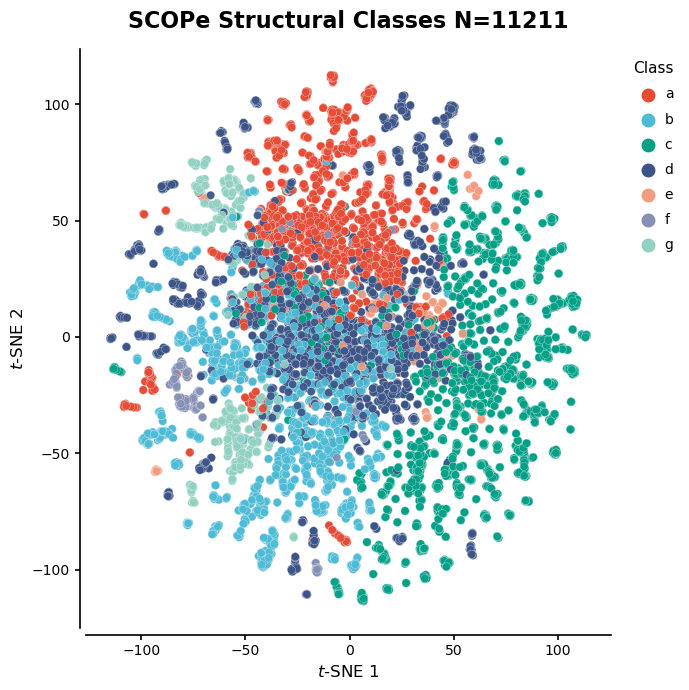

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

NPG_8_COLORS = [
    "#E64B35",
    "#4DBBD5",
    "#00A087",
    "#3C5488",
    "#F39B7F",
    "#8491B4",
    "#91D1C2",
    "#7E6148" 
]

def plot_scope_nature(df):
    fig, ax = plt.subplots(figsize=(7, 7))
    sns.scatterplot(
        data=df,
        x='tSNE_1',
        y='tSNE_2',
        hue='Class',
        hue_order=sorted(df['Class'].unique()),
        palette=NPG_8_COLORS,
        s=35,             
        alpha=0.9,         
        edgecolor='white', 
        linewidth=0.2,     
        ax=ax
    )

    ax.set_title(f'SCOPe Structural Classes N=11211', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('$t$-SNE 1', fontsize=12)
    ax.set_ylabel('$t$-SNE 2', fontsize=12)

    ax.tick_params(axis='both', which='major', labelsize=10, width=1.2) # 加粗刻度线
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.legend(
        bbox_to_anchor=(1.02, 1), 
        loc='upper left', 
        title='Class',
        title_fontsize=11,
        fontsize=10,
        frameon=False,
        markerscale=1.5,
        labelspacing=0.8,
        handletextpad=0.2
    )

    sns.despine(ax=ax, offset=5, trim=False)

    plt.tight_layout()
    plt.show()

plot_scope_nature(df_plot)

## Figure 1D & S1D

In [16]:
%%bash
cd ../RELIC_data/figure1CD/scope_test/
# Generate rocx
methods=("my_model_clean")

for method in "${methods[@]}"; do
    ./bench_roc.awk ./scop_lookup.tsv <(cat ./search_result/${method}) > ./rocx/${method}.rocx
    sort -k3,3 -gr ./search_result/${method} > ./prx/sorted_search_result/${method}
    ./bench_pr.awk ./scop_lookup.tsv <(cat ./prx/sorted_search_result/${method}) > ./prx/${method}.prx
done
cd ../..

/home/gzy/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


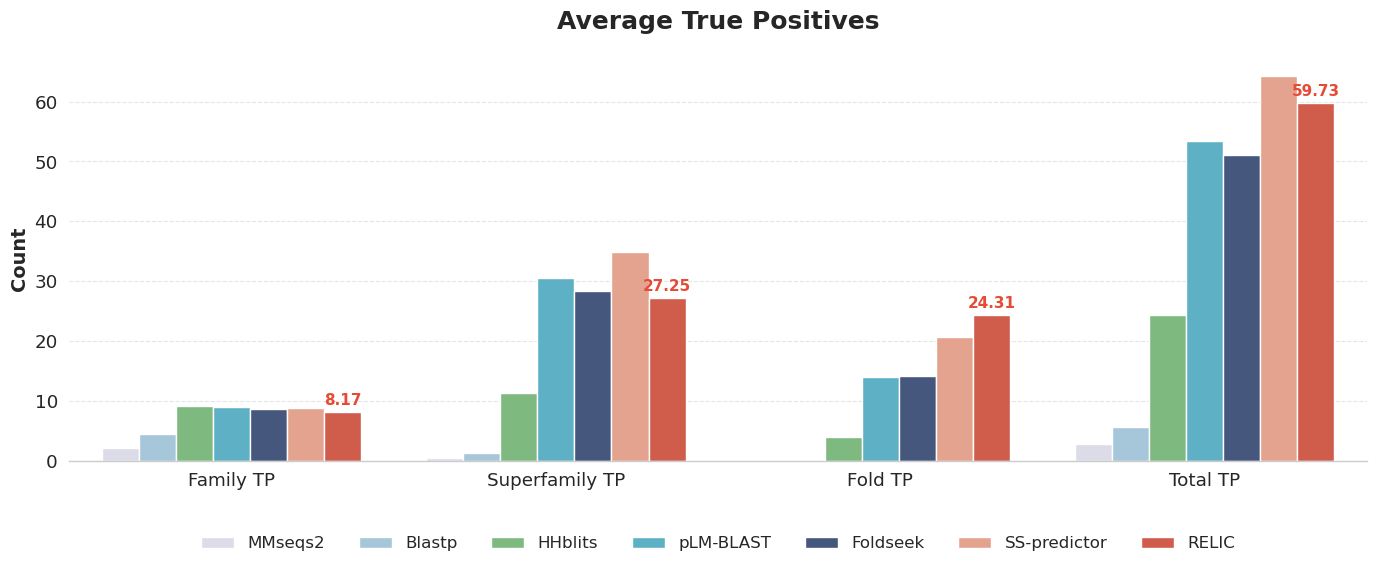

In [17]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

WORK_DIR = "../RELIC_data/figure1CD/scope_test/"

bash_cmd = f"""
cd {WORK_DIR}
methods=("mmseqs2" "blastp" "hhblits" "eat" "plm_blast" "foldseek" "foldseek_tm"  "ss_predictor" "my_model_clean")

for method in "${{methods[@]}}"; do
    echo "Processing method: $method"
    awk '{{ famsum+=$3; supfamsum+=$4; foldsum+=$5}}END{{print famsum/NR,supfamsum/NR,foldsum/NR}}' ./rocx/${{method}}.rocx
    awk '{{ FamTP+=$10; SFamTP+=$11; FoldTP+=$12; TP+=$10; TP+=$11; TP+=$12}}END{{print FamTP/NR, SFamTP/NR, FoldTP/NR, TP/NR}}' ./rocx/${{method}}.rocx
done
"""

result = subprocess.run(bash_cmd, shell=True, executable='/bin/bash', capture_output=True, text=True)
raw_output_str = result.stdout

def parse_raw_data_robust(text):
    if not text: return pd.DataFrame()
    
    lines = text.strip().split('\n')
    data_tp = []
    
    name_map = {
        "mmseqs2": "MMseqs2", "blastp": "Blastp", "hhblits": "HHblits", "eat": "EAT",
        "plm_blast": "pLM-BLAST", "foldseek": "Foldseek", "foldseek_tm": "Foldseek-TM",
        "tmaln": "TM-align", "ss_predictor": "SS-predictor", "plmsearch": "PLMSearch",
        "plmalign_plmsearch": "PLMSearch + PLMAlign", 
        "my_model_clean": "RELIC" 
    }

    current_method = None
    state = "find_method" 
    
    for line in lines:
        line = line.strip()
        if not line: continue 

        if "Processing method:" in line:
            raw_name = line.split(": ")[1].strip()
            current_method = name_map.get(raw_name, raw_name)
            state = "expect_auc"
        
        elif state == "expect_auc" and current_method:
            state = "expect_tp"
            
        elif state == "expect_tp" and current_method:
            parts = line.split()
            if len(parts) == 4:
                try:
                    vals = [float(x) for x in parts]
                    data_tp.append({
                        "Method": current_method,
                        "Family TP": vals[0], "Superfamily TP": vals[1], 
                        "Fold TP": vals[2], "Total TP": vals[3]
                    })
                    state = "find_method"
                except ValueError: pass

    return pd.DataFrame(data_tp)

df_tp = parse_raw_data_robust(raw_output_str)

TARGET_ORDER = [
    "MMseqs2", "Blastp", "HHblits", 
    "pLM-BLAST", "Foldseek", "SS-predictor", 
    "RELIC" 
]

if not df_tp.empty:
    df_tp = df_tp[df_tp["Method"].isin(TARGET_ORDER)]

palette_design = {
    "RELIC": "#E64B35", 
    "MMseqs2": "#DADAEB", 
    "Blastp": "#9ECAE1", 
    "HHblits": "#74C476", 
    "pLM-BLAST": "#4DBBD5", 
    "Foldseek": "#3C5488", 
    "SS-predictor": "#F39B7F"
}

def plot_metrics_auto(df, metric_cols, title, ylabel):
    if df.empty:
        print(f"No data available for '{title}'.")
        return
    df_melt = df.melt(id_vars="Method", value_vars=metric_cols, var_name="Metric", value_name="Value")
    df_melt["Method"] = pd.Categorical(df_melt["Method"], categories=TARGET_ORDER, ordered=True)
    df_melt = df_melt.sort_values("Method")
    df_melt["Metric"] = pd.Categorical(df_melt["Metric"], categories=metric_cols, ordered=True)
    df_melt = df_melt.sort_values("Metric")

    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.5)

    ax = sns.barplot(
        data=df_melt, x="Metric", y="Value", hue="Method",
        palette=palette_design, edgecolor="white", linewidth=1
    )

    for container in ax.containers:
        if container.get_label() == "RELIC":
            ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, fontweight='bold', color='#E64B35')

    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.ylabel(ylabel, fontsize=14, fontweight='bold')
    plt.xlabel("")
    plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=7, frameon=False, fontsize=12)
    sns.despine(left=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_metrics_auto(df_tp, ["Family TP", "Superfamily TP", "Fold TP", "Total TP"], "Average True Positives", "Count")

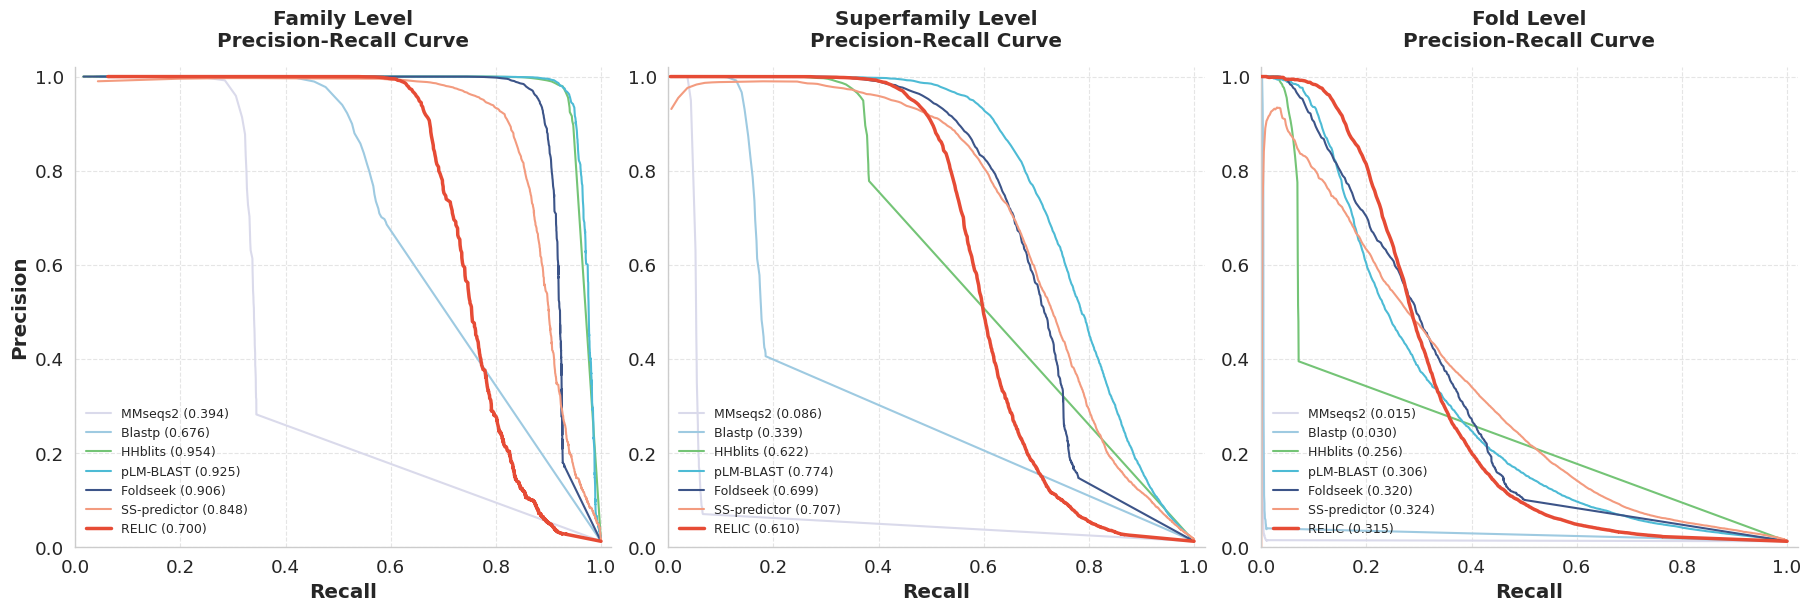

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc
import os

alnresult_dir = "../RELIC_data/figure1CD/scope_test/prx/"

ORDER = [
    "MMseqs2", "Blastp", "HHblits", 
    "pLM-BLAST", "Foldseek", "SS-predictor", 
    "RELIC"
]

FILE_MAP = {
    "MMseqs2": "mmseqs2.prx",
    "Blastp": "blastp.prx",
    "HHblits": "hhblits.prx",
    "pLM-BLAST": "plm_blast.prx",
    "Foldseek": "foldseek.prx",
    "SS-predictor": "ss_predictor.prx",
    "RELIC": "my_model_clean.prx"
}

palette = {
    "RELIC": "#E64B35",
    "MMseqs2": "#DADAEB",
    "Blastp": "#9ECAE1",
    "HHblits": "#74C476",
    "pLM-BLAST": "#4DBBD5",
    "Foldseek": "#3C5488", 
    "SS-predictor": "#F39B7F",
}

def get_style(name):
    if name == "RELIC":
        return {"linestyle": "-", "linewidth": 2.5, "zorder": 10}
    else:
        return {"linestyle": "-", "linewidth": 1.5, "zorder": 2}
data_store = {model: {} for model in ORDER}

for model in ORDER:
    filename = FILE_MAP[model]
    filepath = os.path.join(alnresult_dir, filename)
    
    if os.path.exists(filepath):
        try:
            df = pd.read_csv(filepath, sep='\s+', header=0)
            df = df.apply(pd.to_numeric, errors='coerce').dropna()
            levels = {
                "Family": ("RECALL_FAM", "PREC_FAM"),
                "Superfamily": ("RECALL_SFAM", "PREC_SFAM"),
                "Fold": ("RECALL_FOLD", "PREC_FOLD")
            }
            
            for lvl, (r_col, p_col) in levels.items():
                if r_col in df.columns and p_col in df.columns:
                    rec = df[r_col].values
                    prec = df[p_col].values
                    
                    # 排序并计算 AUPR
                    sorted_idx = np.argsort(rec)
                    rec_s = rec[sorted_idx]
                    prec_s = prec[sorted_idx]
                    aupr = auc(rec_s, prec_s)
                    
                    data_store[model][lvl] = {
                        "recall": rec_s,
                        "precision": prec_s,
                        "aupr": aupr
                    }
        except Exception as e:
            print(f"Error reading {model}: {e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

chart_configs = [
    ("Family", axes[0]),
    ("Superfamily", axes[1]),
    ("Fold", axes[2])
]

for lvl_name, ax in chart_configs:
    
    for model in ORDER:
        if lvl_name in data_store[model]:
            dat = data_store[model][lvl_name]
            style = get_style(model)
            color = palette[model]
            label_text = f"{model} ({dat['aupr']:.3f})"
            ax.plot(dat['recall'], dat['precision'], label=label_text, color=color, **style)
    ax.set_title(f"{lvl_name} Level\nPrecision-Recall Curve", fontweight='bold', pad=15)
    ax.set_xlabel("Recall", fontweight='bold')
    ax.set_ylabel("Precision" if lvl_name == "Family" else "", fontweight='bold') # 只在第一张显示Y轴标签
    
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(linestyle='--', alpha=0.5)
    ax.legend(frameon=False, fontsize=9, loc='lower left')

for ax in axes:
    sns.despine(ax=ax)

plt.show()